In [1]:
import pandas as pd

url="https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df=pd.read_csv(url)

df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [3]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [4]:
df.shape


(1338, 7)

In [5]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [6]:
X=df.drop("charges",axis=1)
y=df["charges"]

In [7]:
print(X)
print(y)

      age     sex     bmi  children smoker     region
0      19  female  27.900         0    yes  southwest
1      18    male  33.770         1     no  southeast
2      28    male  33.000         3     no  southeast
3      33    male  22.705         0     no  northwest
4      32    male  28.880         0     no  northwest
...   ...     ...     ...       ...    ...        ...
1333   50    male  30.970         3     no  northwest
1334   18  female  31.920         0     no  northeast
1335   18  female  36.850         0     no  southeast
1336   21  female  25.800         0     no  southwest
1337   61  female  29.070         0    yes  northwest

[1338 rows x 6 columns]
0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64


In [8]:
import sklearn

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)

(1070, 6)
(268, 6)


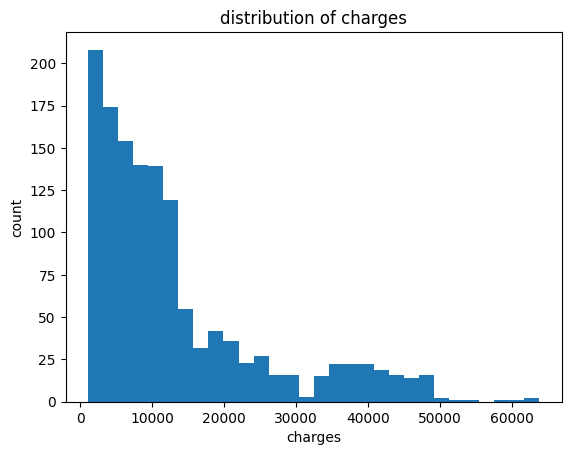

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.hist(df["charges"], bins="fd")
plt.title("distribution of charges")
plt.xlabel("charges")
plt.ylabel("count")
plt.show()

There is a dip at 30000,which is due to partition of data as smokers and non-smokers(Bi-nomial Distribution)

<Axes: xlabel='charges', ylabel='Count'>

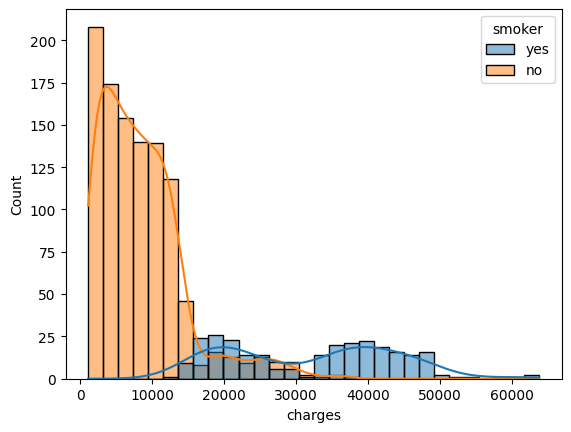

In [11]:
import seaborn as sns

sns.histplot(data=df, x="charges", hue="smoker", kde=True)

<Axes: xlabel='age', ylabel='charges'>

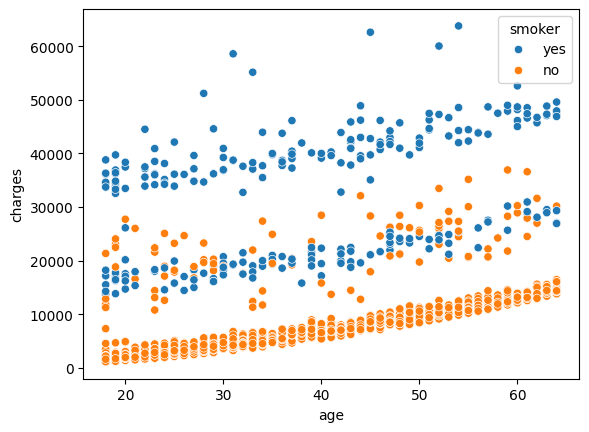

In [12]:
sns.scatterplot(x="age", y="charges", hue="smoker", data=df)



As age increases charges also increases.slope is higher for smokers compared to non-smokers






<Axes: xlabel='bmi', ylabel='charges'>

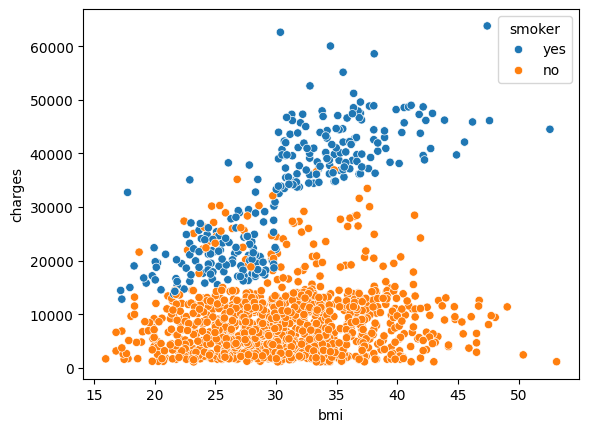

In [13]:
sns.scatterplot(x="bmi", y="charges", hue="smoker", data=df)

It looks like bmi doesnt matter much for non-smokers ,but it plays major role in smokers

<Axes: xlabel='sex', ylabel='charges'>

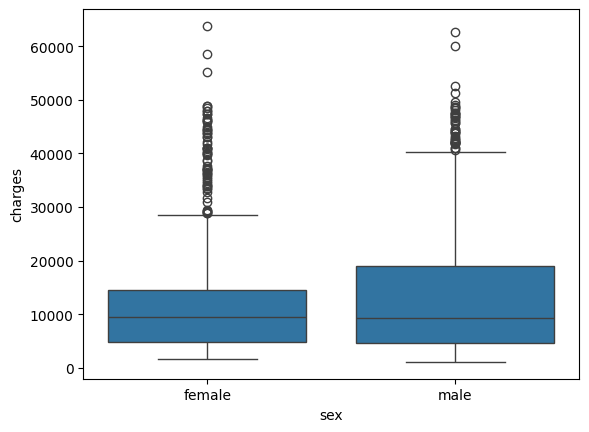

In [14]:
sns.boxplot(x="sex", y="charges", data=df)

<Axes: xlabel='region', ylabel='charges'>

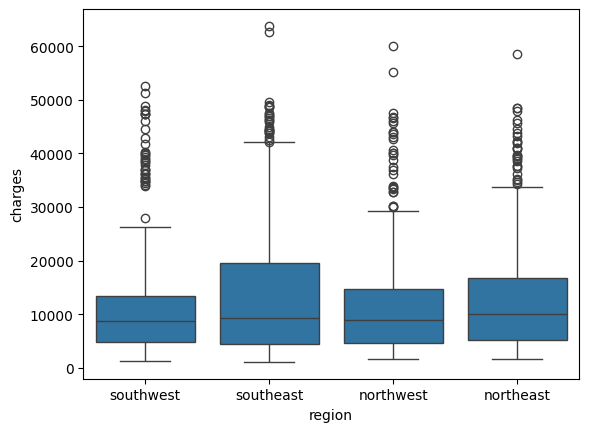

In [15]:
sns.boxplot(x="region", y="charges", data=df)

- Charges are right-skewed with some high-value outliers
- Smoking status is the most important factor affecting charges
- Smokers have significantly higher insurance costs than non-smokers
- Age shows a positive relationship with charges
- BMI alone has weak impact but strongly affects smokers
- Minimal impact observed from sex and region
- Strong feature interactions exist (smoker + BMI, smoker + age)

In [16]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1070 entries, 560 to 1126
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1070 non-null   int64  
 1   sex       1070 non-null   object 
 2   bmi       1070 non-null   float64
 3   children  1070 non-null   int64  
 4   smoker    1070 non-null   object 
 5   region    1070 non-null   object 
dtypes: float64(1), int64(2), object(3)
memory usage: 58.5+ KB


In [17]:
X_train.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0


NO Missing values,three objects

### One-Hot Encoding

One-hot encoding is a process that converts categorical variables into a numerical format, which is more suitable for machine learning algorithms. Each unique category value is converted into a new column, and a 1 is assigned to the column corresponding to the observation's category, with 0s in all other new columns.

In [18]:
X_train_encoded = pd.get_dummies(X_train, columns=['sex', 'smoker', 'region'], drop_first=True, dtype=int)
X_test_encoded = pd.get_dummies(X_test, columns=['sex', 'smoker', 'region'], drop_first=True, dtype=int)

print("X_train_encoded head:")
display(X_train_encoded.head())

print("X_test_encoded head:")
display(X_test_encoded.head())

X_train_encoded head:


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
560,46,19.95,2,0,0,1,0,0
1285,47,24.32,0,0,0,0,0,0
1142,52,24.86,0,0,0,0,1,0
969,39,34.32,5,0,0,0,1,0
486,54,21.47,3,0,0,1,0,0


X_test_encoded head:


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
764,45,25.175,2,0,0,0,0,0
887,36,30.020,0,0,0,1,0,0
890,64,26.885,0,0,1,1,0,0
1293,46,25.745,3,1,0,1,0,0
259,19,31.920,0,1,1,1,0,0


**Linear Regression**


In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

linear_model=LinearRegression()
linear_model.fit(X_train_encoded,y_train)

LinearRegression()

In [20]:
y_predict=linear_model.predict(X_test_encoded)

In [21]:
from sklearn.metrics import mean_absolute_error
import numpy as np

mean_absolute_error(y_test, y_predict)


4181.19447375365

In [22]:
np.sqrt(mean_squared_error(y_test, y_predict))

np.float64(5796.284659276273)

In [23]:
r2_score(y_test, y_predict)

0.7835929767120724

In [24]:
from sklearn.ensemble import RandomForestRegressor
rf_model=RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(X_train_encoded,y_train)
rf_y_predict=rf_model.predict(X_test_encoded)

In [25]:
display("MAE:",mean_absolute_error(y_test, rf_y_predict))
display("MSE:",np.sqrt(mean_squared_error(y_test, rf_y_predict)))
display("r**2:",r2_score(y_test, rf_y_predict))

'MAE:'

2550.0784706115096

'MSE:'

np.float64(4576.299916157115)

'r**2:'

0.8651034329144947

Random Forest performed better than Linear Regression because the data contains non-linear relationships and strong feature interactions.

EDA showed that smoking status creates a clear separation in charges and that BMI and age affect smokers differently. Linear Regression cannot capture these complex patterns, whereas Random Forest can model non-linear relationships and interactions effectively, leading to better performance.

In [26]:
X_test.head()

,age,sex,bmi,children,smoker,region
764,45,female,25.175,2,no,northeast
887,36,female,30.020,0,no,northwest
890,64,female,26.885,0,yes,northwest
1293,46,male,25.745,3,no,northwest
259,19,male,31.920,0,yes,northwest


In [27]:
sample={
    "age" : 19,
    "sex": "female",
    "bmi": 27,
    "children":0,
    "smoker":"yes",
    "region":"southeast"
}
sample_df=pd.DataFrame([sample])
sample_df.head()

,age,sex,bmi,children,smoker,region
0,19,female,27,0,yes,southeast


In [28]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [29]:
sample_encoded = pd.get_dummies(sample_df)
sample_encoded = sample_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)



In [30]:
prediction = rf_model.predict(sample_encoded)
print("Predicted Insurance Cost(RandomForest):", prediction[0])

pred=linear_model.predict(sample_encoded)
print("Predicted Insurance Cost(LinearModel):", pred[0])

Predicted Insurance Cost(RandomForest): 18585.586263600013
Predicted Insurance Cost(LinearModel): 25046.08282227964


In [31]:
residuals = y_test - rf_y_predict

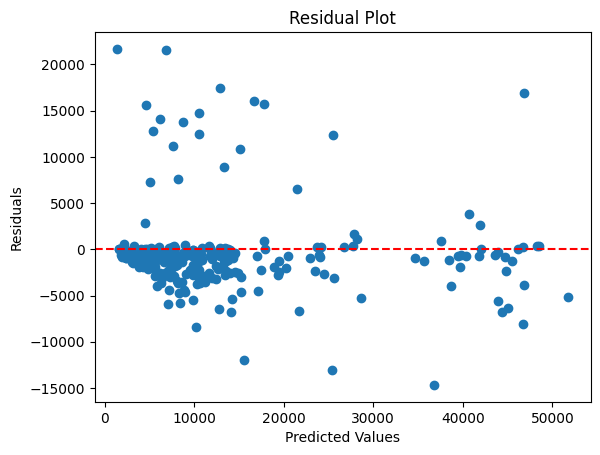

In [32]:

plt.scatter(rf_y_predict, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

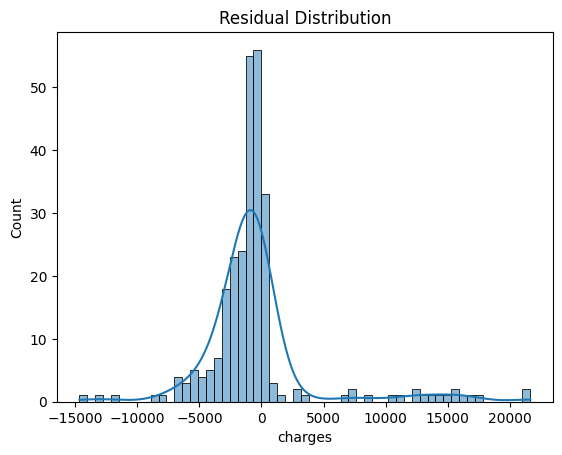

In [33]:
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

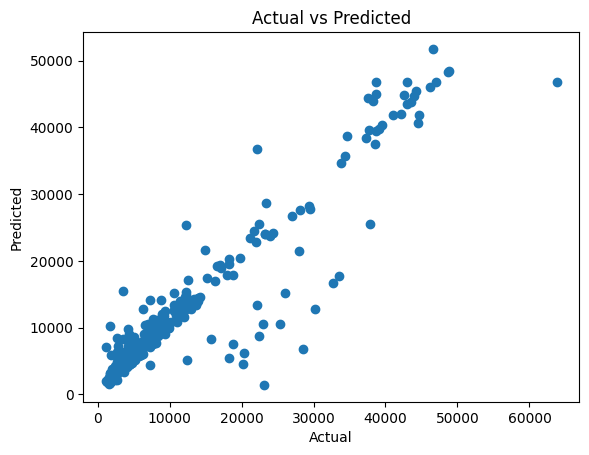

In [34]:
plt.scatter(y_test, rf_y_predict)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

- Residuals are mostly centered around zero, indicating the model is not biased
- Some outliers exist, indicating difficulty in predicting extreme values

Hyper-parameter-tuning


In [35]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [36]:
rf = RandomForestRegressor(random_state=42)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)
grid.fit(X_train_encoded, y_train)
print(grid.best_params_)

{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


In [37]:
best_rf = grid.best_estimator_

y_pred_best = best_rf.predict(X_test_encoded)
print("Tuned R2:", r2_score(y_test, y_pred_best))

Tuned R2: 0.8740887472946735


In [38]:
np.sqrt(mean_squared_error(y_test,y_pred_best))

np.float64(4421.26251912755)

there is a slight improvement after hyper parameter tuning

In [41]:
import joblib
joblib.dump(grid, "model.pkl")

['model.pkl']